# Classifying Forest and Oil Palm Under Persistent Clouds

**Tawau Hills Park (Taman Bukit Tawau), Sabah, Malaysian Borneo**

Tawau Hills Park protects about 280 km² of lowland and hill dipterocarp rainforest on
the slopes of an extinct volcano. Outside its boundary the forest gives way to oil palm
plantations, some reaching the park edge. Telling the two apart from space is a routine
question, and in this part of Borneo also a hard one: of the ~220 Sentinel-2 scenes
acquired over the park every year, only a handful are less than 20% cloudy.

This notebook classifies the park and its surroundings three ways — with Sentinel-2
optical indices alone, with Sentinel-1 radar backscatter alone, and with both in the
same feature stack — and compares them. Radar sees through clouds but not colour;
optical sees colour but not through clouds. The combination is the point.

It uses the **multi-sensor feature stacks** added to `LandCoverClassifier` in
ndvi2gif 1.6.0: several `NdviSeasonality` objects, one per sensor, combined into one
classification.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality, LandCoverClassifier

# ee.Authenticate()          # only the first time
ee.Initialize(project='your-project-id')
print('✓ Earth Engine initialised')

✓ Earth Engine initialised


## 2. Study area

The park boundary comes from the World Database on Protected Areas, available in Earth
Engine. Its WDPA name is *Tawau Hill Park* — filter on the exact name, since the
neighbouring *Tawau Protection Forest* would also match a partial search. The study area
is the bounding box of the park plus 8 km, so that it takes in the plantations around it.

In [2]:
park = (ee.FeatureCollection('WCMC/WDPA/current/polygons')
        .filter(ee.Filter.eq('NAME', 'Tawau Hill Park'))
        .geometry())
area = park.buffer(8000, 100).bounds(100)

print(f"Park:       {park.area(100).divide(1e6).getInfo():6.0f} km²")
print(f"Study area: {area.area(100).divide(1e6).getInfo():6.0f} km²")

Park:          280 km²


Study area:   1702 km²


## 3. How cloudy is it?

With `cloud_filter=True` (the default), `NdviSeasonality` cleans Sentinel-2 in two
steps: it drops whole scenes whose metadata reports more than `max_cloud_cover` percent of
clouds (20 by default), and then masks the cloudy pixels of the remaining scenes with the
Scene Classification Layer (`scl_mask=True`). Let's see what the default leaves for monthly
composites of 2024 over the park, compared with keeping every scene and relying on the pixel
mask alone (`max_cloud_cover=100`).

In [3]:
YEAR = 2024
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def monthly_coverage(max_cloud_cover):
    ns = NdviSeasonality(roi=area, sat='S2', periods=12, start_year=YEAR,
                         end_year=YEAR, index='ndvi', key='median',
                         cloud_filter=True, max_cloud_cover=max_cloud_cover)
    scenes = ee.List([ns.ndvi_col.filterDate(f'{YEAR}{s}', f'{YEAR}{e}').size()
                      for s, e in ns.period_dates])
    covered = ee.List([
        ns.get_period_composite(YEAR, i).mask()
          .reduceRegion(ee.Reducer.mean(), area, 500, maxPixels=1e10)
          .values().get(0)
        for i in range(12)
    ])
    scenes, covered = ee.List([scenes, covered]).getInfo()
    return scenes, [c or 0 for c in covered]

strict = monthly_coverage(max_cloud_cover=20)
relaxed = monthly_coverage(max_cloud_cover=100)

coverage = pd.DataFrame({
    'scenes ≤20% cloud': strict[0],
    'area covered': [f'{c:.0%}' for c in strict[1]],
    'all scenes': relaxed[0],
    'area covered (pixel mask only)': [f'{c:.0%}' for c in relaxed[1]],
}, index=MONTHS)
coverage

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


There we go again...
Applying cloud filter to Sentinel-2: max 100% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


,scenes ≤20% cloud,area covered,all scenes,area covered (pixel mask only)
Jan,0,0%,44,95%
Feb,5,71%,44,99%
Mar,1,29%,48,100%
Apr,2,20%,47,85%
May,3,57%,48,95%
Jun,2,0%,42,72%
Jul,7,87%,48,96%
Aug,1,0%,48,69%
Sep,7,55%,48,92%
Oct,2,0%,48,80%


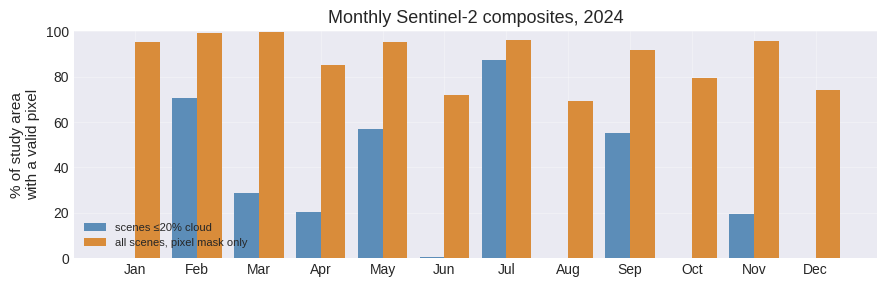

In [4]:
x = np.arange(12)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(x - 0.2, [100 * c for c in strict[1]], 0.4, color='#5c8db8', label='scenes ≤20% cloud')
ax.bar(x + 0.2, [100 * c for c in relaxed[1]], 0.4, color='#d98c3a', label='all scenes, pixel mask only')
ax.set_xticks(x, MONTHS)
ax.set_ylabel('% of study area\nwith a valid pixel')
ax.set_ylim(0, 100)
ax.set_title(f'Monthly Sentinel-2 composites, {YEAR}')
ax.legend(loc='lower left', fontsize=8, frameon=False)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

With the default threshold some months have no scene at all and most of the rest cover
only part of the area. Since ndvi2gif 1.5.1 an empty month is kept as a fully masked
band, so the months stay in their place, and `LandCoverClassifier` leaves those bands
out of the feature stack. The partial months are the real problem: **a pixel masked in
any band of the stack is dropped from the training samples and left unclassified in the
map.** A stack of twelve patchy months would classify only the pixels that happen to be
clear in all of them.

Keeping every scene and masking clouds pixel by pixel does much better, because the
clear patches of 40-60 scenes a month add up. Monthly composites still have holes in
the cloudiest months, though, and a season fills them. The optical stack below therefore
uses **seasonal medians of all scenes with the pixel mask** (`max_cloud_cover=100`). The
price is the haze and cloud edges the Scene Classification Layer misses, which a median
dampens but does not remove.

Note that `cloud_filter=False` is *not* the way to keep every scene: it switches off the
pixel mask as well, and the composites fill up with clouds.

## 4. Reference labels

There is no field survey here, so the reference comes from two global maps:

- **[ESA WorldCover 2021](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200)** (10 m) for tree cover, mangroves, water, built-up land and
  grassland/cropland.
- **[Global oil palm map](https://developers.google.com/earth-engine/datasets/catalog/BIOPAMA_GlobalOilPalm_v1)** (Descals et al., 2021, 10 m, 2019) for industrial and
  smallholder plantations. WorldCover labels oil palm as tree cover, so it is carved out
  of the forest class.

| Class | Value | Source |
|---|---|---|
| Natural forest | 0 | WorldCover tree cover, not oil palm |
| Oil palm | 1 | Global oil palm map (industrial + smallholder) |
| Mangrove | 2 | WorldCover |
| Water | 3 | WorldCover |
| Built-up | 4 | WorldCover |
| Grassland / cropland | 5 | WorldCover |

150 points are drawn per class, so rare classes such as built-up land are represented as
well as the forest. Keep in mind what this measures: agreement with two maps made for
other years (2019 and 2021, against 2024 imagery), including their own errors. It is a
fair yardstick to *compare* the three stacks, not a certified accuracy.

In [5]:
CLASSES = ['Natural forest', 'Oil palm', 'Mangrove', 'Water', 'Built-up',
           'Grassland / cropland']
PALETTE = ['1b5e20', 'c0ca33', '00897b', '1e88e5', 'e53935', 'ffb74d']

worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
oil_palm = (ee.ImageCollection('BIOPAMA/GlobalOilPalm/v1')
            .select('classification').mosaic().lte(2))  # 1 industrial, 2 smallholder

labels = (ee.Image(-1)
          .where(worldcover.eq(10).And(oil_palm.Not()), 0)
          .where(oil_palm, 1)
          .where(worldcover.eq(95), 2)
          .where(worldcover.eq(80), 3)
          .where(worldcover.eq(50), 4)
          .where(worldcover.eq(30).Or(worldcover.eq(40)), 5)
          .rename('class'))
labels = labels.updateMask(labels.gte(0)).toInt()

points = labels.stratifiedSample(numPoints=150, classBand='class', region=area,
                                 scale=30, seed=42, geometries=True)
counts = points.aggregate_histogram('class').getInfo()
pd.Series({CLASSES[int(k)]: v for k, v in counts.items()}, name='points')

Natural forest          150
Oil palm                150
Mangrove                150
Water                   150
Built-up                150
Grassland / cropland    150
Name: points, dtype: int64

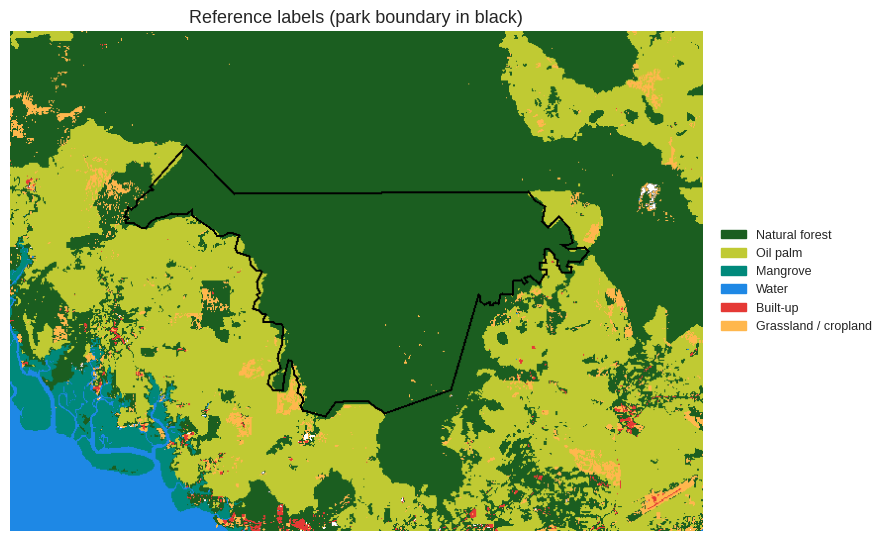

In [6]:
def thumbnail(image, vis, dimensions=700):
    # Static PNG of an ee.Image over the study area
    url = image.visualize(**vis).getThumbURL(
        {'region': area, 'dimensions': dimensions, 'format': 'png'})
    return Image.open(BytesIO(urlopen(url).read()))

def show_classes(ax, img, title):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

class_vis = {'min': 0, 'max': 5, 'palette': PALETTE}
park_outline = ee.Image().byte().paint(park, 1, 2).visualize(palette=['000000'])
legend = [Patch(color='#' + c, label=n) for c, n in zip(PALETTE, CLASSES)]

fig, ax = plt.subplots(figsize=(9, 7))
show_classes(ax, thumbnail(labels.visualize(**class_vis).blend(park_outline), {}),
             'Reference labels (park boundary in black)')
ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout()

## 5. Three feature stacks

One `NdviSeasonality` per sensor, both for 2024 over the same area:

- **Sentinel-2**: seasonal medians (`periods=4`) of NDVI, NDWI and NDMI — greenness,
  surface water and canopy moisture — from every scene, with clouds masked pixel by pixel.
- **Sentinel-1**: monthly medians (`periods=12`) of VV and VH backscatter, which
  respond to canopy structure: the regular rows and open canopy of a plantation
  scatter differently from the multi-layered canopy of a rainforest. ndvi2gif applies
  its analysis-ready preprocessing: a Refined Lee speckle filter and radiometric terrain
  correction, which matters here — the park climbs the slopes of an extinct volcano,
  and a slope facing the radar looks brighter than the same forest on flat ground.

Both sensors are 10 m, so they combine without resampling (section 8 shows what
happens when they differ). With more than one sensor, `create_feature_stack` takes the
indices as a dict and prefixes every band with its sensor.

The three classifiers are trained and validated on the **same points**: those where
every band of the combined stack has a value. Otherwise each would be scored on a
different sample and the comparison would not be fair.

In [7]:
common = dict(roi=area, start_year=YEAR, end_year=YEAR, key='median')
s2 = NdviSeasonality(sat='S2', periods=4, index='ndvi', max_cloud_cover=100, **common)
s1 = NdviSeasonality(sat='S1', periods=12, index='vh', **common)

S2_INDICES = ['ndvi', 'ndwi', 'ndmi']
S1_INDICES = ['vv', 'vh']

def feature_stack(processors, indices):
    clf = LandCoverClassifier(processors)
    # Random forests split each feature on thresholds, so rescaling features
    # changes nothing; skipping the normalization also saves a full pass over
    # the area
    clf.create_feature_stack(indices=indices, include_statistics=True, normalize=False)
    return clf

clf_s2 = feature_stack(s2, S2_INDICES)
clf_s1 = feature_stack(s1, S1_INDICES)
clf_both = feature_stack([s2, s1], {'S2': S2_INDICES, 'S1': S1_INDICES})

There we go again...
Applying cloud filter to Sentinel-2: max 100% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
LandCoverClassifier initialized for S2
Period: 2024-2024, 4 periods/year
Creating feature stack...
  Processing ndvi...


Year 2024: 4/4 periods with data using ndvi index
  Processing ndwi...


Year 2024: 4/4 periods with data using ndwi index
  Processing ndmi...


Year 2024: 4/4 periods with data using ndmi index
  Adding temporal statistics...


Feature stack ready: 24 bands
LandCoverClassifier initialized for S1
Period: 2024-2024, 12 periods/year
Creating feature stack...
  Processing vv...


...

Year 2024: 4/4 periods with data using ndwi index
  Processing S2_ndmi...


Year 2024: 4/4 periods with data using ndmi index
  Processing S1_vv...


Year 2024: 12/12 periods with data using vv index
  Processing S1_vh...


Year 2024: 12/12 periods with data using vh index
  Adding temporal statistics...


Feature stack ready: 56 bands


In [8]:
# Keep the points that have a value in every band of the combined stack
usable = (clf_both.feature_stack
          .sampleRegions(collection=points, properties=['class'], scale=10, geometries=True)
          .select(['class']))
print(f"{usable.size().getInfo()} of {points.size().getInfo()} points usable by all three stacks")

889 of 900 points usable by all three stacks


In [9]:
for clf in (clf_s2, clf_s1, clf_both):
    clf.add_training_data(training_points=usable, class_property='class')
    clf.classify_supervised(algorithm='random_forest', params={'numberOfTrees': 100})

Loading training data...


Training data loaded: 889 samples


Split: 610 training, 279 validation
Training random_forest classifier...
random_forest classification complete


Overall Accuracy: 0.735
Kappa: 0.682
Loading training data...


Training data loaded: 889 samples


Split: 610 training, 279 validation
Training random_forest classifier...
random_forest classification complete


Overall Accuracy: 0.581
Kappa: 0.497
Loading training data...


Training data loaded: 889 samples


Split: 610 training, 279 validation
Training random_forest classifier...
random_forest classification complete


Overall Accuracy: 0.763
Kappa: 0.716


## 6. Accuracy

Each classifier trains on 70% of the points and is validated on the other 30%. The
split is deterministic and the points are the same, so the three are scored on exactly
the same validation sample.

In [10]:
runs = {'Sentinel-2 only': clf_s2, 'Sentinel-1 only': clf_s1,
        'Sentinel-2 + Sentinel-1': clf_both}

summary = pd.DataFrame({
    name: {'features': clf.feature_stack.bandNames().size().getInfo(),
           'overall accuracy': clf.accuracy_results['overall_accuracy'],
           'kappa': clf.accuracy_results['kappa']}
    for name, clf in runs.items()
}).T
summary.style.format({'features': '{:.0f}', 'overall accuracy': '{:.2f}', 'kappa': '{:.2f}'})

,features,overall accuracy,kappa
Sentinel-2 only,24,0.73,0.68
Sentinel-1 only,32,0.58,0.50
Sentinel-2 + Sentinel-1,56,0.76,0.72


In [11]:
per_class = pd.DataFrame({
    name: clf.get_accuracy_report().set_index('Class')['ProducerAccuracy'].drop('Overall')
    for name, clf in runs.items()
})
per_class.index = [CLASSES[int(i)] for i in per_class.index]
per_class.style.format('{:.2f}').set_caption("Producer's accuracy per class")

,Sentinel-2 only,Sentinel-1 only,Sentinel-2 + Sentinel-1
Natural forest,0.52,0.54,0.65
Oil palm,0.57,0.52,0.57
Mangrove,0.98,0.85,0.96
Water,1.00,1.00,1.00
Built-up,0.86,0.24,0.90
Grassland / cropland,0.40,0.30,0.42


The combined stack agrees best with the reference: overall accuracy rises from 0.73
with Sentinel-2 alone to 0.76, and kappa from 0.68 to 0.72. Radar alone lags well
behind (0.58), which is expected — backscatter says a lot about structure and water and
little about the things optical sees, such as the bright roofs of built-up land (0.24).

The gain concentrates where it was wanted. **Natural forest** goes from 0.52 to 0.65:
the canopy of a rainforest and that of a mature oil palm plantation are both closed and
green, and it is structure — what the radar measures — that tells them apart. **Oil palm**
itself stays at 0.57 whatever the stack. Part of that is the reference, not the
classifier: the oil palm map is from 2019, and five years is long enough for plantations
to be felled, replanted or abandoned, so some of the 2024 "errors" are changes on the
ground. Water, mangrove and built-up land are easy for any stack that includes optical
data.

## 7. Maps

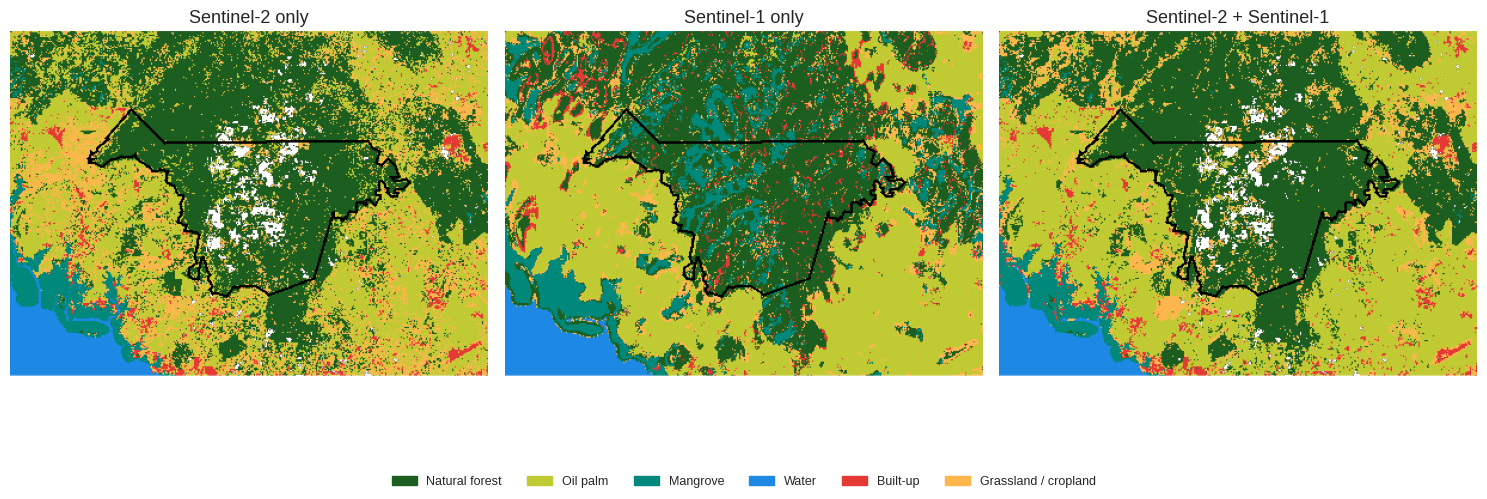

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, (name, clf) in zip(axes, runs.items()):
    img = clf.classified_image.visualize(**class_vis).blend(park_outline)
    show_classes(ax, thumbnail(img, {}, dimensions=400), name)
fig.legend(handles=legend, loc='lower center', ncol=6, fontsize=9, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))

The Sentinel-1 map is complete; the two maps with Sentinel-2 have white holes inside the
park, around the summit, where cloud did not clear in a whole season. That is the rule
from section 3 at work: **a pixel masked in any band of the stack stays unclassified**.
Radar has no such gaps, so the simplest remedy is to fill the holes of the combined map
with the radar-only one:

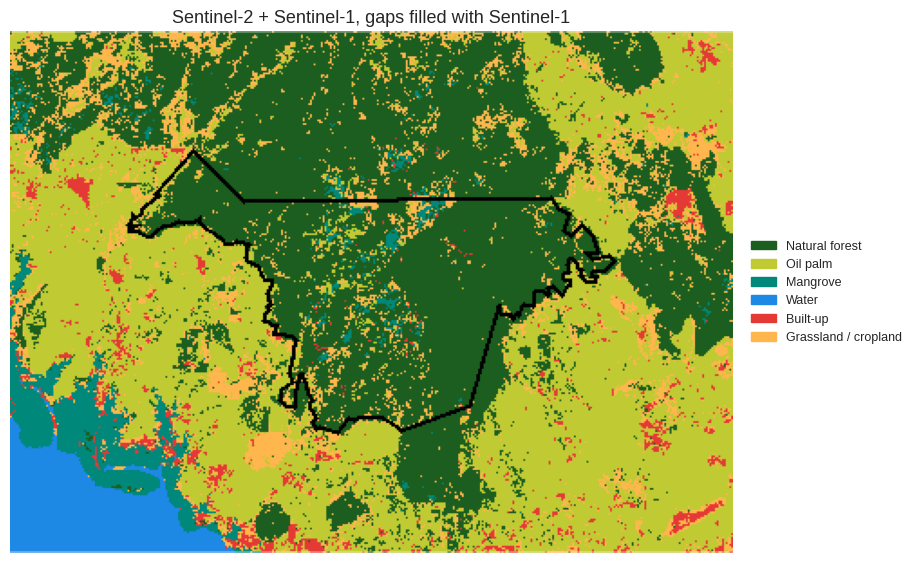

In [13]:
filled = clf_both.classified_image.unmask(clf_s1.classified_image)

fig, ax = plt.subplots(figsize=(9, 6))
show_classes(ax, thumbnail(filled.visualize(**class_vis).blend(park_outline), {}, dimensions=400),
             'Sentinel-2 + Sentinel-1, gaps filled with Sentinel-1')
ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout()

The holes are gone, but look at what filled them: scattered *mangrove* pixels on the
slopes of the park, where no mangrove can grow. The filled pixels carry the weaknesses of
the radar-only classification — here, confusing hill forest seen at a steep angle with the
dense, flooded canopy of a mangrove. Gap filling is a practical fix, not a free one: flag
the filled pixels, or add a rule such as masking mangrove above a few metres of elevation
with a DEM.

To explore the maps interactively, add them to a `geemap` map:

```python
import geemap
Map = geemap.Map()
Map.centerObject(area, 11)
Map.addLayer(clf_both.classified_image, class_vis, 'Sentinel-2 + Sentinel-1')
Map.addLayer(clf_s2.classified_image, class_vis, 'Sentinel-2 only', False)
Map.addLayer(park, {'color': 'black'}, 'Tawau Hill Park')
Map
```

## 8. What drives the combined classification

`get_feature_importance()` ranks the bands of the stack by how much the random forest
relied on them.

S1    0.53
S2    0.47


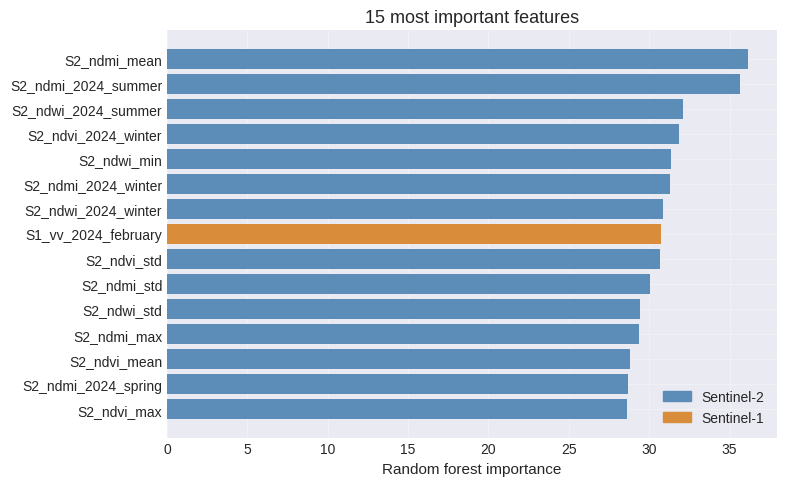

In [14]:
importance = pd.Series(clf_both.get_feature_importance())
top = importance.head(15)[::-1]
colors = ['#5c8db8' if name.startswith('S2_') else '#d98c3a' for name in top.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel('Random forest importance')
ax.set_title('15 most important features')
ax.legend(handles=[Patch(color='#5c8db8', label='Sentinel-2'),
                   Patch(color='#d98c3a', label='Sentinel-1')], loc='lower right')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

share = importance.groupby(importance.index.str.split('_').str[0]).sum()
print((share / share.sum()).round(2).to_string())

Sentinel-2 features take the top of the ranking — canopy moisture (NDMI) and water (NDWI)
above all, in summer and as yearly means — with a single radar feature among the first
fifteen. Yet Sentinel-1 accounts for about half of the total importance: its contribution
is spread over many monthly bands, each weak on its own, which together add the structural
information the optical indices lack. Importance in a random forest is shared among
correlated features, so read it as a ranking within this model, not as a measure of how
much each sensor is worth in general.

## 9. Taking the model elsewhere

`export_model()` writes what is needed to repeat the classification or to re-fit it
outside Earth Engine: a JSON with the full configuration (processors, feature stack,
training setup, algorithm and parameters), the model as Earth Engine describes it — every
tree of the random forest as text, the feature importance, the out-of-bag error — and the
accuracy; and a CSV with every sample, its coordinates, class, features and split.

In [15]:
paths = clf_both.export_model('results/tawau_s2_s1_rf')

import json
model = json.load(open(paths['model']))
print('Algorithm: ', model['classifier']['algorithm'], model['classifier']['parameters'])
print('Features:  ', len(model['features']), model['features'][:3], '...')
print('OOB error: ', round(model['classifier']['explain']['outOfBagErrorEstimate'], 3))
print()
print(model['classifier']['explain']['trees'][0][:600], '...')

Model written to results/tawau_s2_s1_rf.json, samples to results/tawau_s2_s1_rf_samples.csv
Algorithm:  random_forest {'numberOfTrees': 100, 'variablesPerSplit': None, 'minLeafPopulation': 1, 'bagFraction': 0.5, 'maxNodes': None}
Features:   56 ['S2_ndvi_2024_winter', 'S2_ndvi_2024_spring', 'S2_ndvi_2024_summer'] ...
OOB error:  0.272

n= 306
node), split, n, loss, yval, (yprob)
* denotes terminal node
1) root 306 254.91 1 (0.16026 0.17628 0.16987 0.16346 0.15705 0.17308)
 2) S1_vv_2024_april<=-16.3250 49 0.0000 3 (0.018182 0.018182 0.018182 0.90909 0.018182 0.018182) *
 3) S1_vv_2024_april>-16.3250 257 205.89 1 (0.19011 0.20913 0.20152 0.0076046 0.18631 0.20532)
  6) S2_ndmi_2024_summer<=0.461172 216 167.05 1 (0.22523 0.24775 0.058559 0.0045045 0.22072 0.24324)
   12) S2_ndvi_2024_winter<=0.584090 62 28.677 4 (0.029412 0.044118 0.088235 0.014706 0.66176 0.16176)
    24) S2_ndwi_2024_summer<=-0.563970 4 2.0000 1 (0.10000 0.3 ...


In [16]:
samples = pd.read_csv(paths['samples'])
samples.iloc[:5, :8]

,lon,lat,class,split,S2_ndvi_2024_winter,S2_ndvi_2024_spring,S2_ndvi_2024_summer,S2_ndvi_2024_autumn
0,118.035260,4.345196,0,train,0.820609,0.813850,0.780555,0.776541
1,118.106945,4.443292,0,train,0.875855,0.885203,0.889458,0.818966
2,117.936625,4.528991,0,train,0.829844,0.793832,0.794630,0.750899
3,117.782743,4.561600,0,train,0.838718,0.815077,0.841442,0.808880
4,117.960879,4.469972,0,train,0.844954,0.754307,0.756095,0.826979


The trees are documentation — no other library loads them — but the CSV is enough to
fit an equivalent model elsewhere, for instance in scikit-learn. It will not be identical
tree by tree, because each implementation draws its own random numbers:

```python
from sklearn.ensemble import RandomForestClassifier

train = samples[samples.split == 'train']
rf = RandomForestClassifier(n_estimators=model['classifier']['parameters']['numberOfTrees'])
rf.fit(train[model['features']], train['class'])
```

## 10. Sensors with different resolutions

Sentinel-1 and Sentinel-2 share a 10 m grid. Combine Sentinel-2 with Landsat (30 m) and
the classifier needs to know how to reconcile them — and refuses to guess, because the
two options mean different things:

In [17]:
landsat = NdviSeasonality(sat='Landsat', periods=4, index='ndvi', **common)

try:
    LandCoverClassifier([s2, landsat])
except ValueError as e:
    print(e)

There we go again...
Applying cloud filter to Landsat: max 20% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering
The sensors have different resolutions (S2 10 m, Landsat 30 m). Choose how to combine them with resample='coarser' (mean aggregation to the coarsest grid), resample='finer' (bilinear interpolation to the finest grid) or resample=<meters>.


In [18]:
coarse = LandCoverClassifier([s2, landsat], resample='coarser')  # S2 averaged to 30 m
fine = LandCoverClassifier([s2, landsat], resample='finer')      # Landsat interpolated to 10 m
custom = LandCoverClassifier([s2, landsat], resample=20)         # both to 20 m

LandCoverClassifier initialized for S2, Landsat
Period: 2024-2024, 4 periods/year
Feature stack at 30 m on EPSG:32650 (native: S2 10 m, Landsat 30 m)


LandCoverClassifier initialized for S2, Landsat
Period: 2024-2024, 4 periods/year
Feature stack at 10 m on EPSG:32650 (native: S2 10 m, Landsat 30 m)


LandCoverClassifier initialized for S2, Landsat
Period: 2024-2024, 4 periods/year
Feature stack at 20 m on EPSG:32650 (native: S2 10 m, Landsat 30 m)


- `'coarser'` averages each block of 10 m Sentinel-2 pixels into the 30 m Landsat grid.
  Nothing is invented, detail is lost.
- `'finer'` interpolates Landsat bilinearly to 10 m. The map keeps Sentinel-2's detail,
  but the Landsat bands are smoothed, not sharpened: they carry no more information than
  before.
- A number sets the pixel size in meters, aggregating or interpolating each sensor as
  needed.

The common grid is the UTM zone of the study area unless `crs=` is given, so pixel sizes
are true meters.

## 11. Take-aways

- **Check the coverage before choosing the composites.** In persistently cloudy regions a
  scene-level cloud filter leaves months empty; keep every scene and let the pixel mask do
  the work (`cloud_filter=True, max_cloud_cover=100`), and prefer seasons to months if gaps
  remain. `cloud_filter=False` would switch the pixel mask off as well.
- **Sentinel-1 and Sentinel-2 go into one stack** with `LandCoverClassifier([s2, s1])` and
  the indices given per sensor. Here the combination beat either sensor alone, and the gain
  was where optical data struggle: separating natural forest from plantations.
- **Compare stacks on the same points and the same split**: keep the points every stack can
  see, and `add_training_data()` draws the same split for all of them.
- **A pixel masked in any band stays unclassified.** Fill those gaps with a classification
  that does not depend on clear skies, such as the radar-only one.
- **`export_model()`** saves the configuration, the trees and the samples, so the
  classification can be repeated or re-fitted outside Earth Engine.
- The accuracy here is agreement with two global maps made for other years, a fair basis to
  compare stacks, not a certified accuracy. With field data, the same workflow gives the
  real figure.